# Agent LangGraph
## Bez narzędzi

## Importowanie bibliotek

In [2]:
from langchain_core.messages import HumanMessage
from langchain_anthropic import ChatAnthropic
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState
import logging
from IPython.display import Image, Markdown, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles


## Konfiguracja logowania

In [3]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)
logging.basicConfig(
    filename='langgraph_notebook.log',
    level=logging.INFO,
)


## Konfiguracja agenta i modelu

In [4]:
model = ChatAnthropic(model="claude-3-5-sonnet-20240620", temperature=0)
def call_model(state: MessagesState):
        messages = state['messages']
        response = model.invoke(messages)
        return {"messages": [response]}
workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_edge(START, "agent")
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)


## Wizualizacja grafu

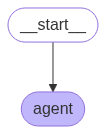

In [6]:
display(
    Image(
            app.get_graph().draw_mermaid_png(
                draw_method=MermaidDrawMethod.API,
            )
    )
)


## Czat z agentem

In [8]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="W jakich zespołach grał Joe Montana?")]},
    config={"configurable": {"thread_id": 99}}
)
display(Markdown(final_state["messages"][-1].content))


Joe Montana grał w dwóch zespołach NFL podczas swojej profesjonalnej kariery futbolowej:

1. San Francisco 49ers (1979-1992): 
Montana spędził większość swojej kariery w 49ers, gdzie stał się legendą i wygrał cztery Super Bowl (XVI, XIX, XXIII i XXIV). To właśnie z tym zespołem jest najbardziej kojarzony.

2. Kansas City Chiefs (1993-1994): 
Po tym jak został wymieniony przez 49ers, Montana rozegrał swoje ostatnie dwa sezony NFL w Chiefs.

Dodatkowo, przed karierą zawodową:

3. University of Notre Dame (1975-1978):
Montana grał w futbol akademicki na Uniwersytecie Notre Dame.

Montana jest powszechnie uważany za jednego z najlepszych rozgrywających w historii NFL, a jego kariera w San Francisco 49ers jest szczególnie pamiętna ze względu na liczne sukcesy i mistrzowskie tytuły.

In [9]:
final_state = app.invoke(
{"messages": [HumanMessage(content="Jakie ligi są dostępne na platformie futbolu fantasy SportsWorldCentral??")]},
    config={"configurable": {"thread_id": 99}}
)
display(Markdown(final_state["messages"][-1].content))


Przepraszam, ale nie mam konkretnych informacji na temat platformy futbolu fantasy o nazwie SportsWorldCentral ani o ligach, które mogą być na niej dostępne. Platformy fantasy sportu często się zmieniają i wprowadzają nowe ligi, więc bez bezpośredniego sprawdzenia tej konkretnej strony nie mogę podać wiarygodnych informacji.

Aby uzyskać aktualne i dokładne informacje o ligach dostępnych na SportsWorldCentral, najlepiej byłoby:

1. Odwiedzić oficjalną stronę internetową SportsWorldCentral.
2. Sprawdzić ich sekcję FAQ lub pomocy.
3. Skontaktować się bezpośrednio z obsługą klienta platformy.
4. Przejrzeć aktualne oferty i opcje rejestracji na stronie.

Przepraszam, że nie mogę podać bardziej szczegółowych informacji. Jeśli masz dostęp do tej platformy, najlepszym źródłem informacji będzie sama strona lub jej obsługa klienta.